In [1]:
from langgraph.graph import StateGraph , START,END 
from langchain_groq import ChatGroq
from typing import TypedDict , Literal , Annotated
from dotenv import load_dotenv
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage , HumanMessage , SystemMessage
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

llm = ChatGroq(
    model="openai/gpt-oss-120b",   # OpenAI's open-weight flagship, strong creative output, native tool-calling
    temperature=0.8,               # higher temp = more varied, punchy tweet drafts
)

In [3]:
class JokeState(TypedDict):
    topic : str
    joke : str
    explaination : str


In [4]:
def generate_joke(state:JokeState):
    
    topic = state["topic"]

    prompt = f"Generate a hilarious joke on topic: {topic} mimicing humans without making it chatbot vibe. User shouldnt be able to distinguish that its ai generated. Generate upto punchline only."

    joke = llm.invoke(prompt).content

    return {"joke":joke}

def explain_joke(state:JokeState):
    joke = state["joke"]

    prompt = f"Explain this joke for me Joke:\n {joke} \n Nont make it too lengthy. Small explaination only explaining the punchline thats it "

    explaination = llm.invoke(prompt).content

    return {"explaination":explaination}



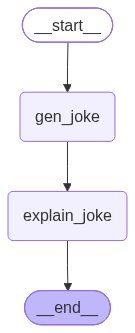

In [5]:
graph = StateGraph(JokeState)

graph.add_node("gen_joke",generate_joke)
graph.add_node("explain_joke",explain_joke)

graph.add_edge(START , "gen_joke")
graph.add_edge("gen_joke","explain_joke")
graph.add_edge("explain_joke",END)

checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)
workflow


In [6]:
config1 = {"configurable":{"thread_id":1} }
input_state = {"topic":"pizza"}
final_state = workflow.invoke(input_state,config=config1)
print(final_state)

{'topic': 'pizza', 'joke': 'I saw my pepperoni standing in line at the DMV, tapping its crust impatiently and whining about the wait—turns out it was just trying to get a slice of the American Dream.', 'explaination': 'The punchline hinges on the word **“slice.”**  \n\n- A pepperoni pizza is made of **slices**, and “getting a slice” literally means taking a piece of pizza.  \n- The phrase **“American Dream”** is often used to describe the ideal of success and opportunity in the United States.  \n- By saying the pepperoni is at the DMV “trying to get a slice of the American Dream,” the joke mixes the literal pizza meaning (a slice of pizza) with the idiomatic expression (a “slice” of the American Dream), creating a humorous double‑meaning.'}


In [7]:
config2 = {"configurable":{"thread_id":2}}
input_state = {"topic":"Daal Bhat"}
final_state = workflow.invoke(input_state,config=config2)
print(final_state)

{'topic': 'Daal Bhat', 'joke': 'I tried to teach my daal‑bhat to act like a human. Now it’s sitting at the table, scrolling through Instagram, and when I ask it for a snack, it says, “Sorry, I’m on a diet—just here for the rice‑cipes!”', 'explaination': 'The punchline hinges on a word‑play: “rice‑cipes” sounds like “recipes” but swaps **rice** (the main part of daal‑bhat) for the “re‑” part. By saying it’s “just here for the rice‑cipes,” the food pretends to be on a diet—like a person avoiding eating itself—while actually just wanting to be part of a cooking guide. The joke is funny because it treats a staple dish as a person who can scroll Instagram, refuse snacks, and make a pun about its own main ingredient.'}


In [8]:

workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'I saw my pepperoni standing in line at the DMV, tapping its crust impatiently and whining about the wait—turns out it was just trying to get a slice of the American Dream.', 'explaination': 'The punchline hinges on the word **“slice.”**  \n\n- A pepperoni pizza is made of **slices**, and “getting a slice” literally means taking a piece of pizza.  \n- The phrase **“American Dream”** is often used to describe the ideal of success and opportunity in the United States.  \n- By saying the pepperoni is at the DMV “trying to get a slice of the American Dream,” the joke mixes the literal pizza meaning (a slice of pizza) with the idiomatic expression (a “slice” of the American Dream), creating a humorous double‑meaning.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18c228-87de-6581-8002-782802e001e1'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-07-30T14:25:37.192437+0

In [9]:

workflow.get_state(config2)


StateSnapshot(values={'topic': 'Daal Bhat', 'joke': 'I tried to teach my daal‑bhat to act like a human. Now it’s sitting at the table, scrolling through Instagram, and when I ask it for a snack, it says, “Sorry, I’m on a diet—just here for the rice‑cipes!”', 'explaination': 'The punchline hinges on a word‑play: “rice‑cipes” sounds like “recipes” but swaps **rice** (the main part of daal‑bhat) for the “re‑” part. By saying it’s “just here for the rice‑cipes,” the food pretends to be on a diet—like a person avoiding eating itself—while actually just wanting to be part of a cooking guide. The joke is funny because it treats a staple dish as a person who can scroll Instagram, refuse snacks, and make a pun about its own main ingredient.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f18c228-9874-6f80-8002-a01a432835de'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-07-30T14:25:38.931872+00:00', parent_config={'confi

In [10]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'I saw my pepperoni standing in line at the DMV, tapping its crust impatiently and whining about the wait—turns out it was just trying to get a slice of the American Dream.', 'explaination': 'The punchline hinges on the word **“slice.”**  \n\n- A pepperoni pizza is made of **slices**, and “getting a slice” literally means taking a piece of pizza.  \n- The phrase **“American Dream”** is often used to describe the ideal of success and opportunity in the United States.  \n- By saying the pepperoni is at the DMV “trying to get a slice of the American Dream,” the joke mixes the literal pizza meaning (a slice of pizza) with the idiomatic expression (a “slice” of the American Dream), creating a humorous double‑meaning.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18c228-87de-6581-8002-782802e001e1'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-07-30T14:25:37.192437+

In [ ]:
list(workflow.get_state_history(config2 ))

[StateSnapshot(values={'topic': 'Daal Bhat', 'joke': 'I tried to teach my daal‑bhat to act like a human. Now it’s sitting at the table, scrolling through Instagram, and when I ask it for a snack, it says, “Sorry, I’m on a diet—just here for the rice‑cipes!”', 'explaination': 'The punchline hinges on a word‑play: “rice‑cipes” sounds like “recipes” but swaps **rice** (the main part of daal‑bhat) for the “re‑” part. By saying it’s “just here for the rice‑cipes,” the food pretends to be on a diet—like a person avoiding eating itself—while actually just wanting to be part of a cooking guide. The joke is funny because it treats a staple dish as a person who can scroll Instagram, refuse snacks, and make a pun about its own main ingredient.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f18c228-9874-6f80-8002-a01a432835de'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-07-30T14:25:38.931872+00:00', parent_config={'conf

## Time Travel 


In [14]:
workflow.get_state({'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f18c228-882a-6853-8000-f1cccdf5cd12'}})

StateSnapshot(values={'topic': 'Daal Bhat'}, next=('gen_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f18c228-882a-6853-8000-f1cccdf5cd12'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-30T14:25:37.223648+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f18c228-8823-6ba3-bfff-e52c01fc1a49'}}, tasks=(PregelTask(id='38482860-6468-e08a-555c-d2b446738e5c', name='gen_joke', path=('__pregel_pull', 'gen_joke'), error=None, interrupts=(), state=None, result={'joke': 'I tried to teach my daal‑bhat to act like a human. Now it’s sitting at the table, scrolling through Instagram, and when I ask it for a snack, it says, “Sorry, I’m on a diet—just here for the rice‑cipes!”'}),), interrupts=())

In [15]:
workflow.invoke(None , {'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f18c228-882a-6853-8000-f1cccdf5cd12'}})

{'topic': 'Daal Bhat',
 'joke': 'I walked into the cafeteria and saw a steaming bowl of daal bhat sitting at a conference table, scrolling through a spreadsheet on a tiny laptop. It kept saying, “I’m just here for the rice‑cognition!” and when someone asked for a break, it replied, “I’m already on a *lentil* pause.” Then it stood up, stretched its lentils, and shouted, “Time to *spice* up the meeting—anyone need a *bean* of advice?” \n\nPunchline: It’s the only dish that can *dal*iver a presentation and still be *bhat*ched in the same breath!',
 'explaination': 'The punch‑line plays on the Nepali dish **“dal bhat”** (lentil soup\u202f+\u202frice) and English words that sound similar:\n\n- **“dal”** sounds like **“deliver”** → “the only dish that can *dal‑iver* a presentation.”\n- **“bhat”** sounds like **“batched”** (grouped together) → “and still be *bhat‑ched* in the same breath.”\n\nSo the joke is that this single plate of dal bhat can both **deliver** a talk and be **batched** (ser

In [16]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'Daal Bhat', 'joke': 'I walked into the cafeteria and saw a steaming bowl of daal bhat sitting at a conference table, scrolling through a spreadsheet on a tiny laptop. It kept saying, “I’m just here for the rice‑cognition!” and when someone asked for a break, it replied, “I’m already on a *lentil* pause.” Then it stood up, stretched its lentils, and shouted, “Time to *spice* up the meeting—anyone need a *bean* of advice?” \n\nPunchline: It’s the only dish that can *dal*iver a presentation and still be *bhat*ched in the same breath!', 'explaination': 'The punch‑line plays on the Nepali dish **“dal bhat”** (lentil soup\u202f+\u202frice) and English words that sound similar:\n\n- **“dal”** sounds like **“deliver”** → “the only dish that can *dal‑iver* a presentation.”\n- **“bhat”** sounds like **“batched”** (grouped together) → “and still be *bhat‑ched* in the same breath.”\n\nSo the joke is that this single plate of dal bhat can both **deliver** a talk and

## Update State

In [17]:
workflow.get_state({'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f18c228-882a-6853-8000-f1cccdf5cd12'}})

StateSnapshot(values={'topic': 'Daal Bhat'}, next=('gen_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f18c228-882a-6853-8000-f1cccdf5cd12'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-30T14:25:37.223648+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f18c228-8823-6ba3-bfff-e52c01fc1a49'}}, tasks=(PregelTask(id='38482860-6468-e08a-555c-d2b446738e5c', name='gen_joke', path=('__pregel_pull', 'gen_joke'), error=None, interrupts=(), state=None, result={'joke': 'I tried to teach my daal‑bhat to act like a human. Now it’s sitting at the table, scrolling through Instagram, and when I ask it for a snack, it says, “Sorry, I’m on a diet—just here for the rice‑cipes!”'}),), interrupts=())

In [18]:
workflow.update_state({'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f18c228-882a-6853-8000-f1cccdf5cd12'}},{'topic':"samosa"})

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f18c313-94c4-6621-8001-969e04d3a7f3'}}

In [19]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'samosa'}, next=('gen_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f18c313-94c4-6621-8001-969e04d3a7f3'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-07-30T16:10:46.778165+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f18c228-882a-6853-8000-f1cccdf5cd12'}}, tasks=(PregelTask(id='88f4c939-bce9-e4f3-83cf-e5b3213ef2bf', name='gen_joke', path=('__pregel_pull', 'gen_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'Daal Bhat', 'joke': 'I walked into the cafeteria and saw a steaming bowl of daal bhat sitting at a conference table, scrolling through a spreadsheet on a tiny laptop. It kept saying, “I’m just here for the rice‑cognition!” and when someone asked for a break, it replied, “I’m already on a *lentil* pause.” Then it stood up, stretched its lentils, and shouted, “T

In [20]:
workflow.invoke(None , {'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f18c313-94c4-6621-8001-969e04d3a7f3'}})

{'topic': 'samosa',
 'joke': 'I saw a samosa at the office pretending to be me on a Zoom call—when the boss asked for a “crisp” update, it replied, “Sorry, I’m a little stuffed today.”',
 'explaination': 'The punchline hinges on wordplay with “crisp” and “stuffed,” terms that describe both food and a person’s state:\n\n- **“Crisp”** – In a business context the boss wants a clear, sharp (crisp) update. In cooking, “crisp” describes the crunchy exterior of a fried samosa.  \n- **“Stuffed”** – A person can feel “stuffed” after eating a lot, but a samosa is literally filled (stuffed) with spiced filling.\n\nSo when the samosa (pretending to be the employee) says, “I’m a little stuffed today,” it jokes that it can’t give a crisp update because it’s a food item that’s both crispy on the outside and literally stuffed inside. The humor comes from treating the samosa as if it were a coworker and using food‑related meanings of the words.'}

In [21]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'I saw a samosa at the office pretending to be me on a Zoom call—when the boss asked for a “crisp” update, it replied, “Sorry, I’m a little stuffed today.”', 'explaination': 'The punchline hinges on wordplay with “crisp” and “stuffed,” terms that describe both food and a person’s state:\n\n- **“Crisp”** – In a business context the boss wants a clear, sharp (crisp) update. In cooking, “crisp” describes the crunchy exterior of a fried samosa.  \n- **“Stuffed”** – A person can feel “stuffed” after eating a lot, but a samosa is literally filled (stuffed) with spiced filling.\n\nSo when the samosa (pretending to be the employee) says, “I’m a little stuffed today,” it jokes that it can’t give a crisp update because it’s a food item that’s both crispy on the outside and literally stuffed inside. The humor comes from treating the samosa as if it were a coworker and using food‑related meanings of the words.'}, next=(), config={'configurable': {'